<div style="background:#0f172a; color:white; padding:28px 32px; border-radius:12px; font-family:Arial, sans-serif; border:1px solid #1e293b;">
  <h2 style="margin:8px 0 0 0; font-size:22px; font-weight:500; color:#dbeafe;">Logistic Regression for Binary Classification</h2>
  <p style="margin:16px 0 0 0; font-size:15px; line-height:1.55; color:#e5e7eb; max-width:980px;">
    This notebook covers the Logistic Regression part of the Day 12 topic title. Logistic Regression is used for classification, not ordinary numeric regression. We model a business-style campaign response problem, interpret probabilities, tune decision thresholds, evaluate classification quality, and translate the model into BI-ready recommendations.
  </p>
  <p style="margin:12px 0 0 0; font-size:14px; color:#bfdbfe;">
  <b>Ruturaj Mokashi</b>
  </p>
</div>

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">0. How to Use This Notebook</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    <p><b>Workflow:</b> read the blue explanation, run the short code cell, then read the green conclusion generated from the actual output.</p>
    <p><b>Why this notebook exists:</b> the Day 12 MVD tasks focus mainly on Linear Regression, regularized regression, and GLMs. However, the Day 12 topic title says <b>Linear & Logistic Regression</b>. Therefore, this notebook completes the missing Logistic Regression part.</p>
    <p><b>Dataset note:</b> the notebook first looks for a local file named <code>data/customer_campaign_response.csv</code>. If it is not present, it creates a deterministic business-style campaign response dataset so the notebook remains fully executable and reviewable.</p>
  </div>
</div>

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">1. Controlling Coverage Matrix</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    <p>This table controls Notebook 4 coverage. The goal is to cover Logistic Regression deeply enough for a Data Analyst / BI use case, not just train a model and print accuracy.</p>
    <table style="border-collapse:collapse; width:100%; font-size:14px;">
      <tr style="background:#dbeafe;">
        <th style="border:1px solid #bfdbfe; padding:8px; text-align:left;">Topic</th>
        <th style="border:1px solid #bfdbfe; padding:8px; text-align:left;">Notebook Coverage</th>
        <th style="border:1px solid #bfdbfe; padding:8px; text-align:left;">Status</th>
      </tr>
      <tr><td style="border:1px solid #dbeafe; padding:8px;">Logistic Regression core idea</td><td style="border:1px solid #dbeafe; padding:8px;">Probability prediction, sigmoid and classification threshold</td><td style="border:1px solid #dbeafe; padding:8px;">Planned</td></tr>
      <tr><td style="border:1px solid #dbeafe; padding:8px;">Binary classification workflow</td><td style="border:1px solid #dbeafe; padding:8px;">Train/test split, preprocessing, model fitting, probability prediction</td><td style="border:1px solid #dbeafe; padding:8px;">Planned</td></tr>
      <tr><td style="border:1px solid #dbeafe; padding:8px;">Classification metrics</td><td style="border:1px solid #dbeafe; padding:8px;">Accuracy, precision, recall, F1, ROC-AUC, PR-AUC and log loss</td><td style="border:1px solid #dbeafe; padding:8px;">Planned</td></tr>
      <tr><td style="border:1px solid #dbeafe; padding:8px;">Confusion matrix</td><td style="border:1px solid #dbeafe; padding:8px;">BI-ready TP, FP, TN, FN interpretation</td><td style="border:1px solid #dbeafe; padding:8px;">Planned</td></tr>
      <tr><td style="border:1px solid #dbeafe; padding:8px;">ROC and Precision-Recall curves</td><td style="border:1px solid #dbeafe; padding:8px;">Ranking quality and imbalance-sensitive evaluation</td><td style="border:1px solid #dbeafe; padding:8px;">Planned</td></tr>
      <tr><td style="border:1px solid #dbeafe; padding:8px;">Coefficient interpretation</td><td style="border:1px solid #dbeafe; padding:8px;">Log-odds and odds ratios</td><td style="border:1px solid #dbeafe; padding:8px;">Planned</td></tr>
      <tr><td style="border:1px solid #dbeafe; padding:8px;">Threshold tuning</td><td style="border:1px solid #dbeafe; padding:8px;">Compare thresholds and choose a business-friendly cutoff</td><td style="border:1px solid #dbeafe; padding:8px;">Planned</td></tr>
      <tr><td style="border:1px solid #dbeafe; padding:8px;">Class imbalance</td><td style="border:1px solid #dbeafe; padding:8px;">Use class weights and compare with default model</td><td style="border:1px solid #dbeafe; padding:8px;">Planned</td></tr>
      <tr><td style="border:1px solid #dbeafe; padding:8px;">Calibration</td><td style="border:1px solid #dbeafe; padding:8px;">Calibration curve and Brier score</td><td style="border:1px solid #dbeafe; padding:8px;">Planned</td></tr>
      <tr><td style="border:1px solid #dbeafe; padding:8px;">BI marketing layer</td><td style="border:1px solid #dbeafe; padding:8px;">Lift/gains chart and campaign targeting recommendation</td><td style="border:1px solid #dbeafe; padding:8px;">Planned</td></tr>
    </table>
  </div>
</div>

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 8px 0; color:#1e3a8a; font-size:19px;">2. Core Idea — Logistic Regression in Simple Words</h3>
    <p><b>Simple idea:</b> Linear Regression predicts a number like sales or bike rentals. Logistic Regression predicts the probability of a class, such as <b>will respond</b> or <b>will not respond</b>.</p>
    <p>It first calculates a normal linear score using features and coefficients. Then it passes that score through the <b>sigmoid function</b>, which squeezes any value into a probability between 0 and 1.</p>
    <p>After that, we choose a <b>threshold</b>. If the probability is above the threshold, we predict class 1. If it is below the threshold, we predict class 0. The threshold is a business decision, not a fixed law.</p>
    <table style="border-collapse:collapse; width:100%; font-size:14px;">
      <tr style="background:#dbeafe;"><th style="border:1px solid #bfdbfe; padding:8px; text-align:left;">Concept</th><th style="border:1px solid #bfdbfe; padding:8px; text-align:left;">Plain Meaning</th><th style="border:1px solid #bfdbfe; padding:8px; text-align:left;">Business Example</th></tr>
      <tr><td style="border:1px solid #dbeafe; padding:8px;"><b>Probability</b></td><td style="border:1px solid #dbeafe; padding:8px;">Chance of class 1.</td><td style="border:1px solid #dbeafe; padding:8px;">Customer has 72% chance of responding.</td></tr>
      <tr><td style="border:1px solid #dbeafe; padding:8px;"><b>Threshold</b></td><td style="border:1px solid #dbeafe; padding:8px;">Cutoff used to convert probability into yes/no.</td><td style="border:1px solid #dbeafe; padding:8px;">Send campaign if probability ≥ 0.40.</td></tr>
      <tr><td style="border:1px solid #dbeafe; padding:8px;"><b>Odds ratio</b></td><td style="border:1px solid #dbeafe; padding:8px;">How a feature changes the odds of class 1.</td><td style="border:1px solid #dbeafe; padding:8px;">Higher email click rate may increase response odds.</td></tr>
    </table>
  </div>
</div>

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">3. Project Setup and Display Helpers</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    <p>This cell creates relative folders and HTML helper functions. These helpers keep the notebook consistent, print-ready, and easy to scan.</p>
    <p><b>Variable flow:</b> <code>PROJECT_DIR</code> points to the current notebook folder. <code>DATA_DIR</code> stores optional local CSV files. <code>OUTPUT_DIR</code> can store exported charts or tables later.</p>
  </div>
</div>

In [1]:
# ============================================================
# CELL 1 — PROJECT SETUP AND PRINT-READY DISPLAY HELPERS
# ============================================================

# pathlib creates clean relative paths without exposing personal folders.
from pathlib import Path

# HTML and display create formatted notebook messages.
from IPython.display import HTML, display

# PROJECT_DIR is the current folder where this notebook runs.
PROJECT_DIR = Path.cwd()

# DATA_DIR is used if a local campaign dataset is added later.
DATA_DIR = PROJECT_DIR / "data"

# OUTPUT_DIR can store optional exported outputs.
OUTPUT_DIR = PROJECT_DIR / "outputs"

# Create folders safely if they do not exist.
DATA_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)

# Green conclusion box used after every important code output.
def show_conclusion(title, body):
    """Display a green output-aware conclusion box."""
    display(HTML(f"""
    <div style="border-left:6px solid #16a34a; background:#f0fdf4; padding:14px 18px; border-radius:8px; font-family:Arial, sans-serif; margin:14px 0; line-height:1.60;">
      <h4 style="margin:0 0 8px 0; color:#166534; font-size:18px;">{title}</h4>
      <div style="color:#14532d; font-size:14.5px;">{body}</div>
    </div>
    """))

# Blue information box used for important explanatory notes.
def show_info(title, body):
    """Display a blue information box."""
    display(HTML(f"""
    <div style="border-left:6px solid #2563eb; background:#eff6ff; padding:14px 18px; border-radius:8px; font-family:Arial, sans-serif; margin:14px 0; line-height:1.60;">
      <h4 style="margin:0 0 8px 0; color:#1e3a8a; font-size:18px;">{title}</h4>
      <div style="color:#1e3a8a; font-size:14.5px;">{body}</div>
    </div>
    """))

show_conclusion(
    "Setup complete",
    f"The notebook uses relative folders only: <code>{DATA_DIR.name}/</code> for data and <code>{OUTPUT_DIR.name}/</code> for outputs. No personal path is used."
)

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">4. Import Libraries</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    <p>This cell imports data handling, plotting, preprocessing, Logistic Regression, classification metrics, calibration tools, and train/test splitting.</p>
    <p><b>Important:</b> there is no inline package installation. This keeps the notebook stable and avoids kernel crashes.</p>
  </div>
</div>

In [2]:
# ============================================================
# CELL 2 — IMPORT LIBRARIES
# ============================================================

# Core data tools.
import numpy as np
import pandas as pd

# Matplotlib is used for all charts to keep the notebook stable and portable.
import matplotlib.pyplot as plt

# Warnings are filtered to keep the notebook clean.
import warnings
warnings.filterwarnings("ignore")

# Train/test split and preprocessing tools.
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

# Logistic Regression model.
from sklearn.linear_model import LogisticRegression

# Classification metrics and diagnostic tools.
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, log_loss,
    confusion_matrix, roc_curve, precision_recall_curve,
    brier_score_loss
)
from sklearn.calibration import calibration_curve

# Display settings make tables easier to read.
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

show_conclusion(
    "Libraries imported",
    "All required tools are available for Logistic Regression, preprocessing, classification metrics, calibration, threshold tuning and BI-ready plotting."
)

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">5. Load or Create a Business-Style Binary Classification Dataset</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    <p>For Logistic Regression, we need a binary target. Here the target is <code>responded</code>, where 1 means the customer responded to a campaign and 0 means they did not.</p>
    <p>The notebook checks for <code>data/customer_campaign_response.csv</code>. If the file is unavailable, it creates a deterministic fallback dataset with realistic BI variables: tenure, spend, visits, email engagement, discount usage, support tickets, region and acquisition channel.</p>
    <p><b>Why this is useful:</b> the model output can directly support campaign targeting, customer scoring, and BI dashboard decisions.</p>
  </div>
</div>

In [3]:
# ============================================================
# CELL 3 — LOAD LOCAL FILE OR CREATE FALLBACK DATASET
# ============================================================

# Local dataset path. If this file exists, the notebook uses it.
local_file = DATA_DIR / "customer_campaign_response.csv"

# Create a reproducible random generator for fallback data.
rng = np.random.default_rng(42)

if local_file.exists():
    # If the user provides a local file, read it directly.
    customer_df = pd.read_csv(local_file)
    dataset_source = "Local file: data/customer_campaign_response.csv"
else:
    # Number of customers in the fallback dataset.
    n_customers = 1600

    # Numeric features represent normal customer behavior signals.
    age = rng.integers(21, 68, n_customers)
    tenure_months = rng.integers(1, 84, n_customers)
    monthly_spend = np.round(rng.gamma(shape=4.0, scale=18.0, size=n_customers) + 20, 2)
    website_visits = rng.poisson(lam=5, size=n_customers)
    email_click_rate = np.clip(rng.beta(a=2.2, b=7.5, size=n_customers), 0, 1)
    discount_usage = rng.poisson(lam=1.4, size=n_customers)
    support_tickets = rng.poisson(lam=0.8, size=n_customers)
    previous_purchases = rng.poisson(lam=4.0, size=n_customers)

    # Categorical features add business segmentation context.
    region = rng.choice(["North", "South", "East", "West"], size=n_customers, p=[0.26, 0.24, 0.25, 0.25])
    acquisition_channel = rng.choice(["Organic", "Paid Ads", "Referral", "Email"], size=n_customers, p=[0.35, 0.30, 0.20, 0.15])

    # Convert categorical effects into small numeric effects for realistic target generation.
    channel_effect = pd.Series(acquisition_channel).map({"Organic": 0.00, "Paid Ads": 0.15, "Referral": 0.35, "Email": 0.55}).to_numpy()
    region_effect = pd.Series(region).map({"North": 0.08, "South": -0.08, "East": 0.04, "West": 0.00}).to_numpy()

    # This linear score creates the hidden probability of campaign response.
    linear_score = (
        -3.10
        + 0.012 * tenure_months
        + 0.010 * website_visits
        + 2.85 * email_click_rate
        + 0.009 * previous_purchases
        + 0.060 * discount_usage
        - 0.090 * support_tickets
        + 0.003 * monthly_spend
        + channel_effect
        + region_effect
    )

    # Sigmoid converts the score into a probability between 0 and 1.
    response_probability = 1 / (1 + np.exp(-linear_score))

    # The binary target is sampled from that probability.
    responded = rng.binomial(n=1, p=response_probability)

    # Combine all variables into one dataframe.
    customer_df = pd.DataFrame({
        "age": age,
        "tenure_months": tenure_months,
        "monthly_spend": monthly_spend,
        "website_visits": website_visits,
        "email_click_rate": np.round(email_click_rate, 3),
        "discount_usage": discount_usage,
        "support_tickets": support_tickets,
        "previous_purchases": previous_purchases,
        "region": region,
        "acquisition_channel": acquisition_channel,
        "responded": responded
    })
    dataset_source = "Deterministic fallback business campaign dataset"

# Show the first few rows.
display(customer_df.head())

# Calculate response rate for the conclusion.
response_rate = customer_df["responded"].mean()

show_conclusion(
    "Dataset loaded",
    f"Source: <b>{dataset_source}</b>. The dataset has <b>{customer_df.shape[0]:,}</b> rows and <b>{customer_df.shape[1]}</b> columns. The positive response rate is <b>{response_rate:.1%}</b>, so this is a realistic binary classification problem."
)

,age,tenure_months,monthly_spend,website_visits,email_click_rate,discount_usage,support_tickets,previous_purchases,region,acquisition_channel,responded
0,25,26,73.39,1,0.220,1,0,5,East,Referral,0
1,57,62,61.67,6,0.216,2,0,6,East,Referral,1
2,51,69,58.61,5,0.110,4,0,4,West,Organic,0
3,41,27,53.47,6,0.168,1,1,9,North,Referral,0
4,41,11,114.48,6,0.320,2,0,3,North,Organic,0


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">6. Inspect Dataset Structure and Missing Values</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    <p>Before modeling, we check data types and missing values. Logistic Regression requires a clean feature table and a binary target.</p>
    <p><b>Variable flow:</b> this cell reads <code>customer_df</code> and creates <code>data_quality_df</code>. The result helps confirm whether preprocessing is needed.</p>
  </div>
</div>

In [4]:
# ============================================================
# CELL 4 — DATA QUALITY CHECK
# ============================================================

# Create a compact quality table for each column.
data_quality_df = pd.DataFrame({
    "data_type": customer_df.dtypes.astype(str),
    "missing_values": customer_df.isna().sum(),
    "unique_values": customer_df.nunique()
}).reset_index().rename(columns={"index": "column"})

# Display the table.
display(data_quality_df)

# Calculate total missing values for output interpretation.
total_missing = int(customer_df.isna().sum().sum())

show_conclusion(
    "Data quality checked",
    f"The dataset contains <b>{total_missing}</b> missing values. Numeric and categorical columns are clearly separated, so we can build a clean preprocessing pipeline before Logistic Regression."
)

,column,data_type,missing_values,unique_values
0,age,int64,0,47
1,tenure_months,int64,0,83
2,monthly_spend,float64,0,1500
3,website_visits,int64,0,15
4,email_click_rate,float64,0,483
5,discount_usage,int64,0,7
6,support_tickets,int64,0,6
7,previous_purchases,int64,0,13
8,region,object,0,4
9,acquisition_channel,object,0,4


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">7. Visualize the Target Distribution</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    <p>The target distribution tells us whether the classes are balanced or imbalanced. This matters because accuracy can be misleading when one class is much more common than the other.</p>
    <p><b>Business meaning:</b> if only a small share of customers respond, the model must be judged by precision, recall, PR-AUC, and lift — not only accuracy.</p>
  </div>
</div>

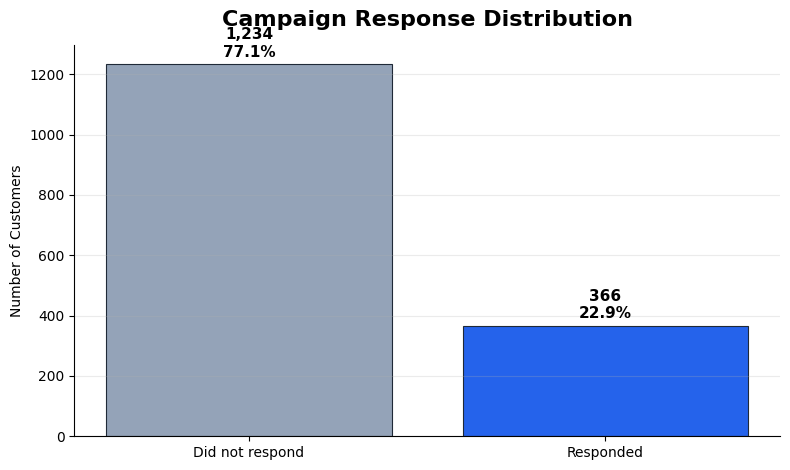

In [5]:
# ============================================================
# CELL 5 — TARGET DISTRIBUTION CHART
# ============================================================

# Count customers in each class.
target_counts = customer_df["responded"].value_counts().sort_index()

# Convert class labels into readable names.
class_names = ["Did not respond", "Responded"]

# Create a clean bar chart.
fig, ax = plt.subplots(figsize=(8, 4.8))
bars = ax.bar(class_names, target_counts.values, color=["#94a3b8", "#2563eb"], edgecolor="#1f2937", linewidth=0.8)

# Add value and percentage labels above the bars.
for bar, value in zip(bars, target_counts.values):
    pct = value / len(customer_df)
    ax.text(bar.get_x() + bar.get_width()/2, value + 15, f"{value:,}\n{pct:.1%}", ha="center", va="bottom", fontsize=11, fontweight="bold")

# Format chart for print-ready output.
ax.set_title("Campaign Response Distribution", fontsize=16, fontweight="bold", pad=14)
ax.set_ylabel("Number of Customers")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

# Calculate imbalance summary.
positive_count = int(target_counts.get(1, 0))
negative_count = int(target_counts.get(0, 0))
positive_rate = positive_count / len(customer_df)

show_conclusion(
    "Target distribution interpreted",
    f"The positive class has <b>{positive_count:,}</b> customers, equal to <b>{positive_rate:.1%}</b> of the dataset. Because responses are less common than non-responses, we will evaluate beyond accuracy using recall, precision, PR-AUC, threshold tuning and lift."
)

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">8. Separate Features and Target</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    <p>We separate the input variables from the target variable.</p>
    <p><b>Variable flow:</b> <code>X</code> contains customer features. <code>y</code> contains the binary target <code>responded</code>. These are used next in the train/test split.</p>
  </div>
</div>

In [6]:
# ============================================================
# CELL 6 — SEPARATE FEATURES AND TARGET
# ============================================================

# Target column for binary classification.
target_column = "responded"

# X contains all columns except the target.
X = customer_df.drop(columns=[target_column])

# y contains only the binary target.
y = customer_df[target_column]

# Identify numeric and categorical features for preprocessing.
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()

# Show feature groups.
print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)
print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

show_conclusion(
    "Features and target separated",
    f"The model will learn from <b>{len(numeric_features)}</b> numeric features and <b>{len(categorical_features)}</b> categorical features. The target is <code>{target_column}</code>, where 1 means customer response."
)

Numeric features: ['age', 'tenure_months', 'monthly_spend', 'website_visits', 'email_click_rate', 'discount_usage', 'support_tickets', 'previous_purchases']
Categorical features: ['region', 'acquisition_channel']
Feature matrix shape: (1600, 10)
Target shape: (1600,)


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">9. Create a Stratified Train/Test Split</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    <p>We split the data into training and testing sets. The model learns only from the training set and is evaluated on the unseen test set.</p>
    <p><b>Stratify matters:</b> because the positive class is less common, <code>stratify=y</code> keeps a similar response rate in both train and test data.</p>
  </div>
</div>

In [7]:
# ============================================================
# CELL 7 — STRATIFIED TRAIN/TEST SPLIT
# ============================================================

# Split the dataset while preserving the target class distribution.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

# Show split shapes and response rates.
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train response rate:", round(y_train.mean(), 4))
print("y_test response rate:", round(y_test.mean(), 4))

show_conclusion(
    "Train/test split completed",
    f"The training set has <b>{X_train.shape[0]:,}</b> rows and the test set has <b>{X_test.shape[0]:,}</b> rows. Stratification kept the response rate similar in train (<b>{y_train.mean():.1%}</b>) and test (<b>{y_test.mean():.1%}</b>)."
)

X_train shape: (1200, 10)
X_test shape: (400, 10)
y_train response rate: 0.2292
y_test response rate: 0.2275


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">10. Build the Preprocessing Pipeline</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    <p>Logistic Regression uses coefficients. For numeric variables, scaling helps make coefficients more stable and comparable. For categorical variables, one-hot encoding converts text categories into numeric columns.</p>
    <p><b>Data leakage warning:</b> scaling and encoding are fitted only on training data through a pipeline. This prevents information from the test set leaking into training.</p>
  </div>
</div>

In [8]:
# ============================================================
# CELL 8 — BUILD PREPROCESSING PIPELINE
# ============================================================

# OneHotEncoder syntax differs slightly across sklearn versions.
try:
    one_hot_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    one_hot_encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

# Numeric variables are scaled. Categorical variables are one-hot encoded.
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", one_hot_encoder, categorical_features)
    ]
)

show_conclusion(
    "Preprocessing pipeline created",
    "The pipeline will scale numeric features and one-hot encode categorical features. This setup is fitted inside the training pipeline, which keeps the test set clean and avoids data leakage."
)

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">11. Train Baseline Logistic Regression</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    <p>This is the first model. It learns the relationship between customer features and campaign response probability.</p>
    <p><b>Important parameter:</b> <code>max_iter=1000</code> gives the optimizer enough iterations to converge cleanly. <code>class_weight</code> is not used yet because this is the baseline model.</p>
  </div>
</div>

In [9]:
# ============================================================
# CELL 9 — TRAIN BASELINE LOGISTIC REGRESSION MODEL
# ============================================================

# Build a full modeling pipeline: preprocessing first, model second.
baseline_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

# Fit the model only on the training data.
baseline_model.fit(X_train, y_train)

show_conclusion(
    "Baseline Logistic Regression trained",
    "The baseline model has learned from the training data. Next we will convert its predicted probabilities into class predictions and evaluate the model on unseen test data."
)

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">12. Predict Probabilities and Classes</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    <p>Logistic Regression naturally outputs probabilities. The default threshold is 0.50, meaning probability ≥ 0.50 becomes class 1.</p>
    <p><b>Variable flow:</b> <code>baseline_prob</code> stores response probabilities. <code>baseline_pred</code> stores yes/no predictions from the 0.50 threshold.</p>
  </div>
</div>

In [10]:
# ============================================================
# CELL 10 — PREDICT PROBABILITIES AND DEFAULT CLASSES
# ============================================================

# Predict probability of class 1: customer responds.
baseline_prob = baseline_model.predict_proba(X_test)[:, 1]

# Convert probabilities into class labels using the default threshold 0.50.
default_threshold = 0.50
baseline_pred = (baseline_prob >= default_threshold).astype(int)

# Show a compact probability sample.
probability_sample = pd.DataFrame({
    "actual_response": y_test.reset_index(drop=True).head(10),
    "predicted_probability": np.round(baseline_prob[:10], 3),
    "predicted_class_at_0_50": baseline_pred[:10]
})

display(probability_sample)

show_conclusion(
    "Probabilities converted to classes",
    f"The model now has two outputs: probabilities for ranking customers and class labels using the default <b>{default_threshold:.2f}</b> threshold. Business teams usually care about both."
)

,actual_response,predicted_probability,predicted_class_at_0_50
0,0,0.423,0
1,0,0.219,0
2,0,0.122,0
3,1,0.138,0
4,0,0.117,0
5,1,0.145,0
6,0,0.115,0
7,0,0.230,0
8,0,0.121,0
9,0,0.202,0


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">13. Evaluate the Baseline Model</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    <p>Accuracy alone is not enough. A campaign model should also show precision, recall, F1, ROC-AUC, PR-AUC and log loss.</p>
    <p><b>Metric meaning:</b> precision means “of the customers we targeted, how many responded?” Recall means “of all real responders, how many did we find?” PR-AUC is useful when the positive class is less common.</p>
  </div>
</div>

In [11]:
# ============================================================
# CELL 11 — BASELINE CLASSIFICATION METRICS
# ============================================================

# Collect key metrics into one dictionary.
baseline_metrics = {
    "Model": "Baseline Logistic Regression",
    "Threshold": default_threshold,
    "Accuracy": accuracy_score(y_test, baseline_pred),
    "Precision": precision_score(y_test, baseline_pred, zero_division=0),
    "Recall": recall_score(y_test, baseline_pred, zero_division=0),
    "F1": f1_score(y_test, baseline_pred, zero_division=0),
    "ROC_AUC": roc_auc_score(y_test, baseline_prob),
    "PR_AUC": average_precision_score(y_test, baseline_prob),
    "Log_Loss": log_loss(y_test, baseline_prob)
}

# Convert metrics into a readable table.
baseline_metrics_df = pd.DataFrame([baseline_metrics])
metric_display_df = baseline_metrics_df.copy()
for col in metric_display_df.columns[2:]:
    metric_display_df[col] = metric_display_df[col].map(lambda x: f"{x:.3f}")

display(metric_display_df)

show_conclusion(
    "Baseline model evaluated",
    f"At threshold <b>{default_threshold:.2f}</b>, the model reaches F1 = <b>{baseline_metrics['F1']:.3f}</b>, ROC-AUC = <b>{baseline_metrics['ROC_AUC']:.3f}</b>, and PR-AUC = <b>{baseline_metrics['PR_AUC']:.3f}</b>. ROC-AUC and PR-AUC evaluate probability ranking, while F1 evaluates the selected threshold."
)

,Model,Threshold,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,Log_Loss
0,Baseline Logistic Regression,0.5,0.777,0.625,0.055,0.101,0.614,0.349,0.521


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">14. Confusion Matrix</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    <p>The confusion matrix shows where the model is right and wrong. It converts abstract metrics into clear business outcomes.</p>
    <p><b>Business meaning:</b> false positives are customers we target who do not respond. False negatives are real responders we missed. The best threshold depends on which mistake is more expensive.</p>
  </div>
</div>

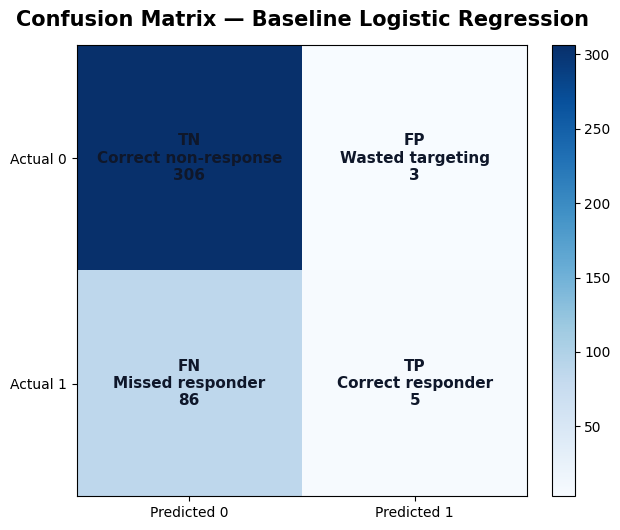

In [12]:
# ============================================================
# CELL 12 — CONFUSION MATRIX CHART
# ============================================================

# Calculate confusion matrix values.
cm = confusion_matrix(y_test, baseline_pred)
tn, fp, fn, tp = cm.ravel()

# Create a clean heatmap-style chart using matplotlib.
fig, ax = plt.subplots(figsize=(6.8, 5.4))
im = ax.imshow(cm, cmap="Blues")

# Add labels and values inside cells.
labels = np.array([["TN\nCorrect non-response", "FP\nWasted targeting"],
                   ["FN\nMissed responder", "TP\nCorrect responder"]])
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{labels[i, j]}\n{cm[i, j]:,}", ha="center", va="center", fontsize=11, fontweight="bold", color="#0f172a")

# Format axes.
ax.set_xticks([0, 1], labels=["Predicted 0", "Predicted 1"])
ax.set_yticks([0, 1], labels=["Actual 0", "Actual 1"])
ax.set_title("Confusion Matrix — Baseline Logistic Regression", fontsize=15, fontweight="bold", pad=14)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

show_conclusion(
    "Confusion matrix interpreted",
    f"The model correctly identifies <b>{tp:,}</b> responders and <b>{tn:,}</b> non-responders. It also creates <b>{fp:,}</b> false positives and misses <b>{fn:,}</b> true responders. This is why threshold tuning is useful."
)

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">15. ROC Curve</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    <p>The ROC curve shows how well the model ranks responders above non-responders across many thresholds.</p>
    <p><b>Interpretation:</b> ROC-AUC close to 1 is strong. ROC-AUC close to 0.5 means the model is not much better than random ranking.</p>
  </div>
</div>

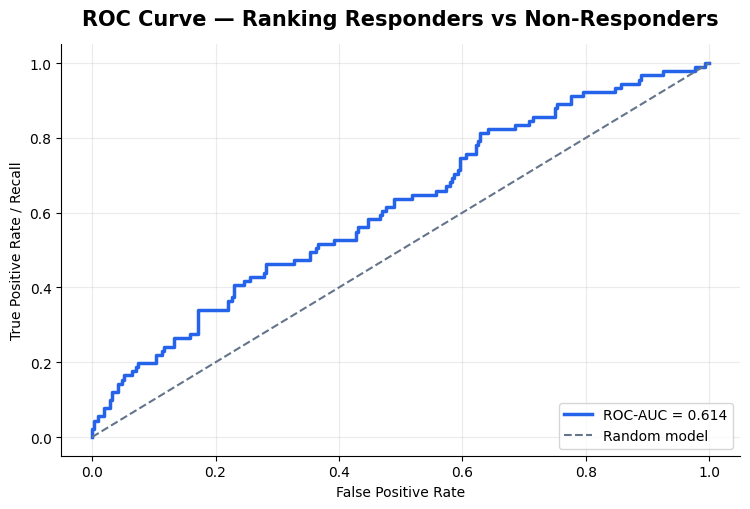

In [13]:
# ============================================================
# CELL 13 — ROC CURVE
# ============================================================

# Calculate ROC curve coordinates.
fpr, tpr, roc_thresholds = roc_curve(y_test, baseline_prob)
roc_auc = roc_auc_score(y_test, baseline_prob)

# Plot ROC curve.
fig, ax = plt.subplots(figsize=(7.6, 5.2))
ax.plot(fpr, tpr, linewidth=2.5, color="#2563eb", label=f"ROC-AUC = {roc_auc:.3f}")
ax.plot([0, 1], [0, 1], linestyle="--", color="#64748b", label="Random model")

# Format chart.
ax.set_title("ROC Curve — Ranking Responders vs Non-Responders", fontsize=15, fontweight="bold", pad=14)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate / Recall")
ax.legend(loc="lower right")
ax.grid(alpha=0.25)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

show_conclusion(
    "ROC curve interpreted",
    f"The ROC-AUC is <b>{roc_auc:.3f}</b>. This means the model has useful ranking power: it tends to assign higher probabilities to responders than to non-responders."
)

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">16. Precision-Recall Curve</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    <p>The Precision-Recall curve is often more useful than ROC when the positive class is less common.</p>
    <p><b>Business meaning:</b> it shows the trade-off between targeting cleaner leads and finding more potential responders.</p>
  </div>
</div>

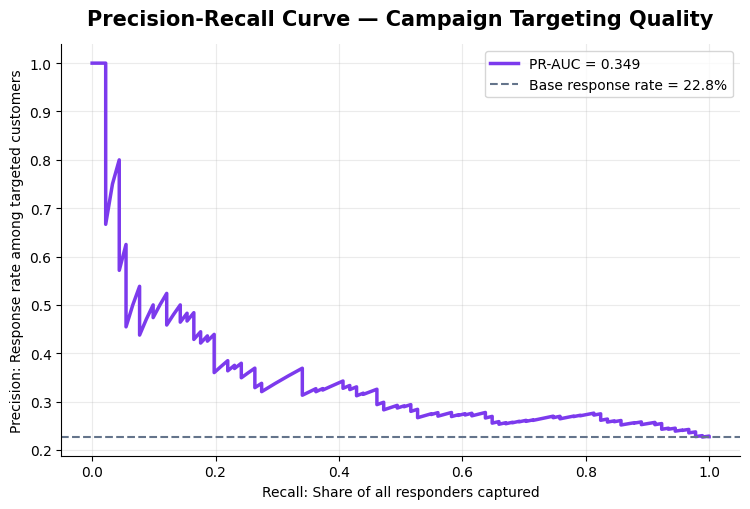

In [14]:
# ============================================================
# CELL 14 — PRECISION-RECALL CURVE
# ============================================================

# Calculate precision-recall curve coordinates.
precision_values, recall_values, pr_thresholds = precision_recall_curve(y_test, baseline_prob)
pr_auc = average_precision_score(y_test, baseline_prob)
base_response_rate = y_test.mean()

# Plot PR curve.
fig, ax = plt.subplots(figsize=(7.6, 5.2))
ax.plot(recall_values, precision_values, linewidth=2.5, color="#7c3aed", label=f"PR-AUC = {pr_auc:.3f}")
ax.axhline(base_response_rate, linestyle="--", color="#64748b", label=f"Base response rate = {base_response_rate:.1%}")

# Format chart.
ax.set_title("Precision-Recall Curve — Campaign Targeting Quality", fontsize=15, fontweight="bold", pad=14)
ax.set_xlabel("Recall: Share of all responders captured")
ax.set_ylabel("Precision: Response rate among targeted customers")
ax.legend(loc="upper right")
ax.grid(alpha=0.25)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

show_conclusion(
    "Precision-Recall curve interpreted",
    f"The PR-AUC is <b>{pr_auc:.3f}</b>, compared with a base response rate of <b>{base_response_rate:.1%}</b>. A strong PR curve means the model can create better campaign targeting lists than random selection."
)

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">17. Visualize the Sigmoid Function</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    <p>The sigmoid function is the heart of Logistic Regression. It converts any linear score into a probability between 0 and 1.</p>
    <p><b>Simple meaning:</b> very negative scores become probabilities near 0, very positive scores become probabilities near 1, and score 0 becomes probability 0.50.</p>
  </div>
</div>

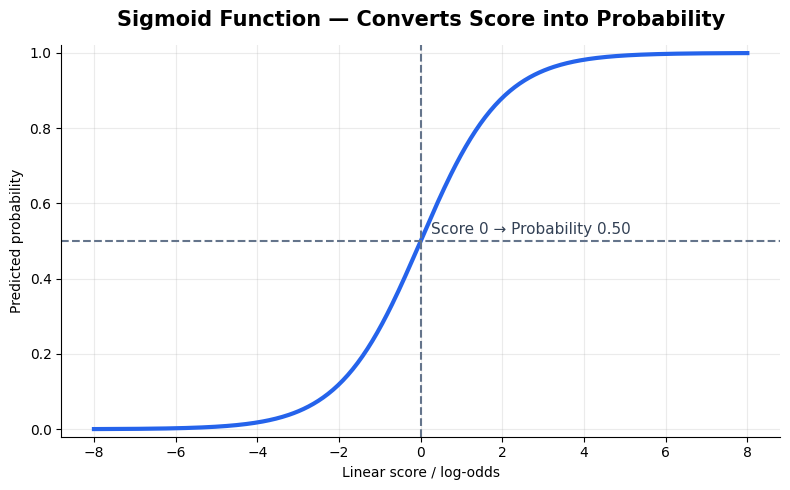

In [15]:
# ============================================================
# CELL 15 — SIGMOID FUNCTION VISUALIZATION
# ============================================================

# Create a range of linear scores from very negative to very positive.
score_values = np.linspace(-8, 8, 400)

# Convert scores to probabilities using the sigmoid formula.
sigmoid_probabilities = 1 / (1 + np.exp(-score_values))

# Plot the sigmoid curve.
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(score_values, sigmoid_probabilities, linewidth=3, color="#2563eb")
ax.axhline(0.5, linestyle="--", color="#64748b", linewidth=1.5)
ax.axvline(0, linestyle="--", color="#64748b", linewidth=1.5)
ax.text(0.25, 0.52, "Score 0 → Probability 0.50", fontsize=11, color="#334155")

# Format chart.
ax.set_title("Sigmoid Function — Converts Score into Probability", fontsize=15, fontweight="bold", pad=14)
ax.set_xlabel("Linear score / log-odds")
ax.set_ylabel("Predicted probability")
ax.set_ylim(-0.02, 1.02)
ax.grid(alpha=0.25)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

show_conclusion(
    "Sigmoid function explained",
    "The sigmoid curve shows why Logistic Regression is useful for classification: it transforms a linear model output into a valid probability between 0 and 1."
)

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">18. Interpret Coefficients and Odds Ratios</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    <p>Logistic Regression coefficients are in log-odds units, which are not always easy to explain. Odds ratios make them easier: an odds ratio above 1 increases response odds, while an odds ratio below 1 decreases response odds.</p>
    <p><b>Variable flow:</b> we extract fitted coefficients from the model, attach feature names after preprocessing, calculate odds ratios, and rank the strongest effects.</p>
  </div>
</div>

In [16]:
# ============================================================
# CELL 16 — COEFFICIENTS AND ODDS RATIOS
# ============================================================

# Access the trained preprocessing step and model step.
fitted_preprocessor = baseline_model.named_steps["preprocess"]
fitted_logistic = baseline_model.named_steps["model"]

# Get final feature names after scaling and one-hot encoding.
feature_names = fitted_preprocessor.get_feature_names_out()

# Get model coefficients for class 1.
coefficients = fitted_logistic.coef_[0]

# Build an interpretation table.
coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient_log_odds": coefficients,
    "odds_ratio": np.exp(coefficients),
    "absolute_effect": np.abs(coefficients)
}).sort_values("absolute_effect", ascending=False)

# Display strongest effects.
display(coef_df.head(12).drop(columns=["absolute_effect"]))

strongest_feature = coef_df.iloc[0]["feature"]
strongest_odds_ratio = coef_df.iloc[0]["odds_ratio"]

show_conclusion(
    "Coefficient table interpreted",
    f"The strongest model signal is <b>{strongest_feature}</b> with an odds ratio of <b>{strongest_odds_ratio:.2f}</b>. Odds ratios above 1 increase response odds; values below 1 reduce response odds."
)

,feature,coefficient_log_odds,odds_ratio
4,num__email_click_rate,0.392056,1.480020
1,num__tenure_months,0.345573,1.412799
12,cat__acquisition_channel_Email,0.312633,1.367019
14,cat__acquisition_channel_Paid Ads,-0.296549,0.743380
13,cat__acquisition_channel_Organic,-0.177035,0.837750
15,cat__acquisition_channel_Referral,0.157872,1.171016
8,cat__region_East,0.151261,1.163300
6,num__support_tickets,-0.136433,0.872465
3,num__website_visits,0.127233,1.135682
11,cat__region_West,-0.119290,0.887550


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">19. Coefficient Impact Chart</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    <p>This chart shows the strongest positive and negative coefficient effects. It helps explain which customer signals push the model toward response or non-response.</p>
    <p><b>Important caution:</b> coefficients are affected by scaling and encoding. They are useful for interpretation, but they are not the same as causal proof.</p>
  </div>
</div>

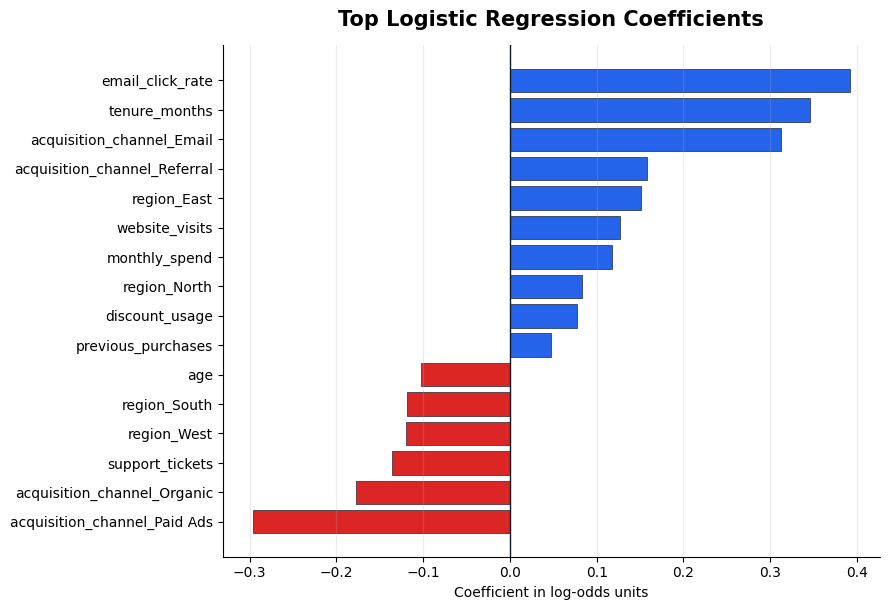

In [17]:
# ============================================================
# CELL 17 — COEFFICIENT IMPACT CHART
# ============================================================

# Select top positive and top negative effects.
top_positive = coef_df.sort_values("coefficient_log_odds", ascending=False).head(8)
top_negative = coef_df.sort_values("coefficient_log_odds", ascending=True).head(8)
impact_df = pd.concat([top_negative, top_positive]).sort_values("coefficient_log_odds")

# Clean feature names for display.
impact_labels = impact_df["feature"].str.replace("num__", "", regex=False).str.replace("cat__", "", regex=False)

# Plot horizontal coefficient impact chart.
fig, ax = plt.subplots(figsize=(9, 6.2))
colors = ["#dc2626" if value < 0 else "#2563eb" for value in impact_df["coefficient_log_odds"]]
ax.barh(impact_labels, impact_df["coefficient_log_odds"], color=colors, edgecolor="#1f2937", linewidth=0.5)
ax.axvline(0, color="#111827", linewidth=1)

# Format chart.
ax.set_title("Top Logistic Regression Coefficients", fontsize=15, fontweight="bold", pad=14)
ax.set_xlabel("Coefficient in log-odds units")
ax.grid(axis="x", alpha=0.25)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

show_conclusion(
    "Coefficient impact visualized",
    "Positive bars push the model toward predicting response. Negative bars push it toward predicting non-response. This gives a business-friendly view of the model drivers."
)

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">20. Tune the Classification Threshold</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    <p>The default threshold 0.50 is not always the best business choice. A lower threshold captures more responders but may target more non-responders. A higher threshold targets fewer customers but may produce a cleaner list.</p>
    <p>Here we test several thresholds and choose the one with the best F1 score. F1 balances precision and recall.</p>
  </div>
</div>

In [18]:
# ============================================================
# CELL 18 — THRESHOLD TUNING TABLE
# ============================================================

# Evaluate thresholds from 0.10 to 0.90.
threshold_rows = []
for threshold in np.arange(0.10, 0.91, 0.05):
    # Convert probabilities to class predictions at this threshold.
    threshold_pred = (baseline_prob >= threshold).astype(int)

    # Store metrics for this threshold.
    threshold_rows.append({
        "Threshold": threshold,
        "Precision": precision_score(y_test, threshold_pred, zero_division=0),
        "Recall": recall_score(y_test, threshold_pred, zero_division=0),
        "F1": f1_score(y_test, threshold_pred, zero_division=0),
        "Targeted_Customers": int(threshold_pred.sum())
    })

# Convert results into a dataframe.
threshold_df = pd.DataFrame(threshold_rows)

# Select the threshold with the highest F1 score.
best_threshold_row = threshold_df.loc[threshold_df["F1"].idxmax()]
best_threshold = float(best_threshold_row["Threshold"])

# Display top threshold options.
display(threshold_df.sort_values("F1", ascending=False).head(8).style.format({
    "Threshold": "{:.2f}",
    "Precision": "{:.3f}",
    "Recall": "{:.3f}",
    "F1": "{:.3f}",
    "Targeted_Customers": "{:.0f}"
}))

show_conclusion(
    "Best threshold selected",
    f"The best F1 threshold is <b>{best_threshold:.2f}</b>. At this threshold, precision is <b>{best_threshold_row['Precision']:.3f}</b>, recall is <b>{best_threshold_row['Recall']:.3f}</b>, and F1 is <b>{best_threshold_row['F1']:.3f}</b>."
)

,Threshold,Precision,Recall,F1,Targeted_Customers
1,0.15,0.262,0.824,0.398,286
0,0.10,0.241,0.967,0.386,365
3,0.25,0.321,0.462,0.378,131
2,0.20,0.272,0.615,0.377,206
4,0.30,0.346,0.308,0.326,81
5,0.35,0.383,0.198,0.261,47
6,0.40,0.500,0.110,0.180,20
7,0.45,0.467,0.077,0.132,15


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">21. Threshold Trade-Off Chart</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    <p>This chart shows how precision, recall and F1 change as the threshold changes. It makes the business trade-off visible.</p>
    <p><b>Business interpretation:</b> if campaign cost is high, prefer higher precision. If missing responders is costly, prefer higher recall.</p>
  </div>
</div>

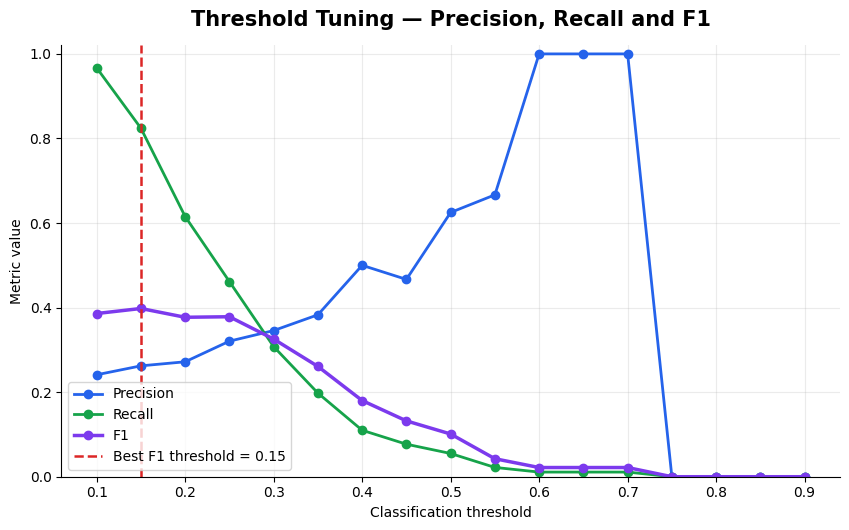

In [19]:
# ============================================================
# CELL 19 — THRESHOLD TRADE-OFF CHART
# ============================================================

# Plot precision, recall and F1 across thresholds.
fig, ax = plt.subplots(figsize=(8.6, 5.4))
ax.plot(threshold_df["Threshold"], threshold_df["Precision"], marker="o", linewidth=2, label="Precision", color="#2563eb")
ax.plot(threshold_df["Threshold"], threshold_df["Recall"], marker="o", linewidth=2, label="Recall", color="#16a34a")
ax.plot(threshold_df["Threshold"], threshold_df["F1"], marker="o", linewidth=2.5, label="F1", color="#7c3aed")
ax.axvline(best_threshold, color="#dc2626", linestyle="--", linewidth=1.8, label=f"Best F1 threshold = {best_threshold:.2f}")

# Format chart.
ax.set_title("Threshold Tuning — Precision, Recall and F1", fontsize=15, fontweight="bold", pad=14)
ax.set_xlabel("Classification threshold")
ax.set_ylabel("Metric value")
ax.set_ylim(0, 1.02)
ax.legend(loc="best")
ax.grid(alpha=0.25)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

show_conclusion(
    "Threshold trade-off visualized",
    f"The chart shows why 0.50 is not automatically best. The best F1 threshold is <b>{best_threshold:.2f}</b>, but the final threshold should still reflect the business cost of false positives versus false negatives."
)

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">22. Compare Default Threshold vs Tuned Threshold</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    <p>Now we compare the default 0.50 threshold with the tuned threshold. The model probabilities are the same, but the business decision rule changes.</p>
    <p><b>Important:</b> threshold tuning does not retrain the model. It only changes how probabilities are converted into class labels.</p>
  </div>
</div>

In [20]:
# ============================================================
# CELL 20 — DEFAULT VS TUNED THRESHOLD COMPARISON
# ============================================================

# Create predictions using the tuned threshold.
tuned_pred = (baseline_prob >= best_threshold).astype(int)

# Create a comparison table.
def classification_summary(model_name, threshold, y_true, y_pred, y_prob):
    """Return key classification metrics in one row."""
    return {
        "Model": model_name,
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_true, y_prob),
        "PR_AUC": average_precision_score(y_true, y_prob),
        "Targeted_Customers": int(y_pred.sum())
    }

threshold_compare_df = pd.DataFrame([
    classification_summary("Baseline Logistic — default 0.50", default_threshold, y_test, baseline_pred, baseline_prob),
    classification_summary("Baseline Logistic — tuned threshold", best_threshold, y_test, tuned_pred, baseline_prob)
])

display(threshold_compare_df.style.format({
    "Threshold": "{:.2f}",
    "Accuracy": "{:.3f}",
    "Precision": "{:.3f}",
    "Recall": "{:.3f}",
    "F1": "{:.3f}",
    "ROC_AUC": "{:.3f}",
    "PR_AUC": "{:.3f}",
    "Targeted_Customers": "{:.0f}"
}))

show_conclusion(
    "Threshold comparison completed",
    f"The tuned threshold changes the campaign decision list from <b>{baseline_pred.sum():,}</b> targeted customers to <b>{tuned_pred.sum():,}</b> targeted customers. This is a business lever, not just a technical metric change."
)

,Model,Threshold,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,Targeted_Customers
0,Baseline Logistic — default 0.50,0.50,0.777,0.625,0.055,0.101,0.614,0.349,8
1,Baseline Logistic — tuned threshold,0.15,0.432,0.262,0.824,0.398,0.614,0.349,286


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">23. Handle Class Imbalance with Class Weights</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    <p>When responders are less common, the model may focus more on the majority class. <code>class_weight='balanced'</code> gives more importance to the minority class during training.</p>
    <p><b>Business meaning:</b> balanced class weights can improve recall, but they may reduce precision. This is useful when finding more responders is more important than keeping the target list small.</p>
  </div>
</div>

In [21]:
# ============================================================
# CELL 21 — TRAIN CLASS-WEIGHTED LOGISTIC REGRESSION
# ============================================================

# Build a second Logistic Regression model with balanced class weights.
balanced_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42))
])

# Fit the balanced model on training data.
balanced_model.fit(X_train, y_train)

# Predict probabilities and default-threshold classes for the test set.
balanced_prob = balanced_model.predict_proba(X_test)[:, 1]
balanced_pred = (balanced_prob >= 0.50).astype(int)

# Summarize performance.
balanced_summary = classification_summary("Balanced Logistic Regression", 0.50, y_test, balanced_pred, balanced_prob)
balanced_metrics_df = pd.DataFrame([balanced_summary])

display(balanced_metrics_df.style.format({
    "Threshold": "{:.2f}",
    "Accuracy": "{:.3f}",
    "Precision": "{:.3f}",
    "Recall": "{:.3f}",
    "F1": "{:.3f}",
    "ROC_AUC": "{:.3f}",
    "PR_AUC": "{:.3f}",
    "Targeted_Customers": "{:.0f}"
}))

show_conclusion(
    "Balanced model trained and evaluated",
    f"The balanced model reaches recall = <b>{balanced_summary['Recall']:.3f}</b> and precision = <b>{balanced_summary['Precision']:.3f}</b>. Compare this with the baseline to decide whether capturing more responders is worth a larger target list."
)

,Model,Threshold,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,Targeted_Customers
0,Balanced Logistic Regression,0.50,0.605,0.287,0.495,0.363,0.613,0.346,157


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">24. Compare Baseline, Tuned and Balanced Models</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    <p>This comparison shows three different business choices: default baseline, tuned threshold, and class-weighted training.</p>
    <p><b>Decision logic:</b> choose the model/threshold that best matches the business objective: clean targeting, high responder capture, or balanced performance.</p>
  </div>
</div>

In [22]:
# ============================================================
# CELL 22 — FINAL CLASSIFICATION MODEL COMPARISON
# ============================================================

# Combine all important model-decision options into one table.
model_comparison_df = pd.DataFrame([
    classification_summary("Baseline Logistic — default 0.50", default_threshold, y_test, baseline_pred, baseline_prob),
    classification_summary("Baseline Logistic — tuned threshold", best_threshold, y_test, tuned_pred, baseline_prob),
    classification_summary("Balanced Logistic — default 0.50", 0.50, y_test, balanced_pred, balanced_prob)
])

# Sort by F1 for a clear summary.
model_comparison_df = model_comparison_df.sort_values("F1", ascending=False).reset_index(drop=True)

display(model_comparison_df.style.format({
    "Threshold": "{:.2f}",
    "Accuracy": "{:.3f}",
    "Precision": "{:.3f}",
    "Recall": "{:.3f}",
    "F1": "{:.3f}",
    "ROC_AUC": "{:.3f}",
    "PR_AUC": "{:.3f}",
    "Targeted_Customers": "{:.0f}"
}))

best_model_name = model_comparison_df.iloc[0]["Model"]
best_model_f1 = model_comparison_df.iloc[0]["F1"]

show_conclusion(
    "Model comparison completed",
    f"The best F1 option is <b>{best_model_name}</b> with F1 = <b>{best_model_f1:.3f}</b>. This table should be used as the main decision summary for the Logistic Regression notebook."
)

,Model,Threshold,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,Targeted_Customers
0,Baseline Logistic — tuned threshold,0.15,0.432,0.262,0.824,0.398,0.614,0.349,286
1,Balanced Logistic — default 0.50,0.50,0.605,0.287,0.495,0.363,0.613,0.346,157
2,Baseline Logistic — default 0.50,0.50,0.777,0.625,0.055,0.101,0.614,0.349,8


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">25. Check Probability Calibration</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    <p>Calibration checks whether predicted probabilities are trustworthy. For example, among customers scored around 70%, roughly 70% should respond if the model is well calibrated.</p>
    <p><b>Business meaning:</b> calibrated probabilities are important if the model score is used for budgeting, forecasting campaign ROI, or ranking customers in a dashboard.</p>
  </div>
</div>

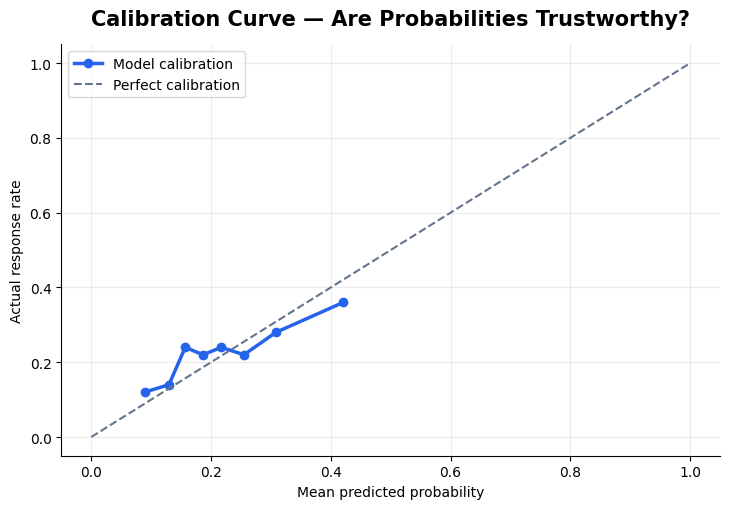

In [23]:
# ============================================================
# CELL 23 — CALIBRATION CURVE AND BRIER SCORE
# ============================================================

# Calculate calibration curve values.
fraction_positive, mean_predicted_value = calibration_curve(y_test, baseline_prob, n_bins=8, strategy="quantile")

# Brier score measures probability error. Lower is better.
brier_score = brier_score_loss(y_test, baseline_prob)

# Plot calibration curve.
fig, ax = plt.subplots(figsize=(7.4, 5.2))
ax.plot(mean_predicted_value, fraction_positive, marker="o", linewidth=2.5, color="#2563eb", label="Model calibration")
ax.plot([0, 1], [0, 1], linestyle="--", color="#64748b", label="Perfect calibration")

# Format chart.
ax.set_title("Calibration Curve — Are Probabilities Trustworthy?", fontsize=15, fontweight="bold", pad=14)
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Actual response rate")
ax.legend(loc="upper left")
ax.grid(alpha=0.25)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

show_conclusion(
    "Calibration checked",
    f"The Brier score is <b>{brier_score:.3f}</b>. Lower is better. The calibration curve shows whether predicted probabilities can be trusted for business forecasting and campaign planning."
)

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">26. Build a Lift and Gains Table</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    <p>Lift and gains analysis is very useful for marketing and BI. It answers: if we target the top-scored customers first, how much better are we than random targeting?</p>
    <p><b>Variable flow:</b> we combine actual test labels and predicted probabilities, rank customers from highest probability to lowest, then split them into deciles.</p>
  </div>
</div>

In [24]:
# ============================================================
# CELL 24 — LIFT AND GAINS TABLE
# ============================================================

# Create a scoring table from test results.
scoring_df = pd.DataFrame({
    "actual_response": y_test.reset_index(drop=True),
    "predicted_probability": baseline_prob
}).sort_values("predicted_probability", ascending=False).reset_index(drop=True)

# Assign customers to deciles. Decile 1 contains the highest probability customers.
scoring_df["decile"] = pd.qcut(scoring_df.index + 1, q=10, labels=False) + 1

# Summarize response rate and lift by decile.
lift_df = scoring_df.groupby("decile").agg(
    customers=("actual_response", "size"),
    responders=("actual_response", "sum"),
    avg_probability=("predicted_probability", "mean"),
    response_rate=("actual_response", "mean")
).reset_index()

# Calculate lift and cumulative capture.
lift_df["lift_vs_average"] = lift_df["response_rate"] / scoring_df["actual_response"].mean()
lift_df["cumulative_responders"] = lift_df["responders"].cumsum()
lift_df["cumulative_capture_rate"] = lift_df["cumulative_responders"] / scoring_df["actual_response"].sum()

# Display the table.
display(lift_df.style.format({
    "avg_probability": "{:.3f}",
    "response_rate": "{:.1%}",
    "lift_vs_average": "{:.2f}x",
    "cumulative_capture_rate": "{:.1%}"
}))

top_decile_lift = lift_df.loc[lift_df["decile"] == 1, "lift_vs_average"].iloc[0]
top_decile_response_rate = lift_df.loc[lift_df["decile"] == 1, "response_rate"].iloc[0]

show_conclusion(
    "Lift table created",
    f"The top-scored decile has a response rate of <b>{top_decile_response_rate:.1%}</b>, giving a lift of <b>{top_decile_lift:.2f}x</b> versus average targeting. This is the strongest BI/business value section of the notebook."
)

,decile,customers,responders,avg_probability,response_rate,lift_vs_average,cumulative_responders,cumulative_capture_rate
0,1,40,17,0.438,42.5%,1.87x,17,18.7%
1,2,40,10,0.332,25.0%,1.10x,27,29.7%
2,3,40,12,0.276,30.0%,1.32x,39,42.9%
3,4,40,8,0.243,20.0%,0.88x,47,51.6%
4,5,40,8,0.214,20.0%,0.88x,55,60.4%
5,6,40,6,0.189,15.0%,0.66x,61,67.0%
6,7,40,14,0.166,35.0%,1.54x,75,82.4%
7,8,40,6,0.143,15.0%,0.66x,81,89.0%
8,9,40,5,0.121,12.5%,0.55x,86,94.5%
9,10,40,5,0.084,12.5%,0.55x,91,100.0%


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">27. Lift Chart</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    <p>The lift chart makes the business value visible. It shows which scored groups are worth targeting first.</p>
    <p><b>Business interpretation:</b> if the top decile has much higher lift than average, the model can reduce campaign waste by prioritizing high-probability customers.</p>
  </div>
</div>

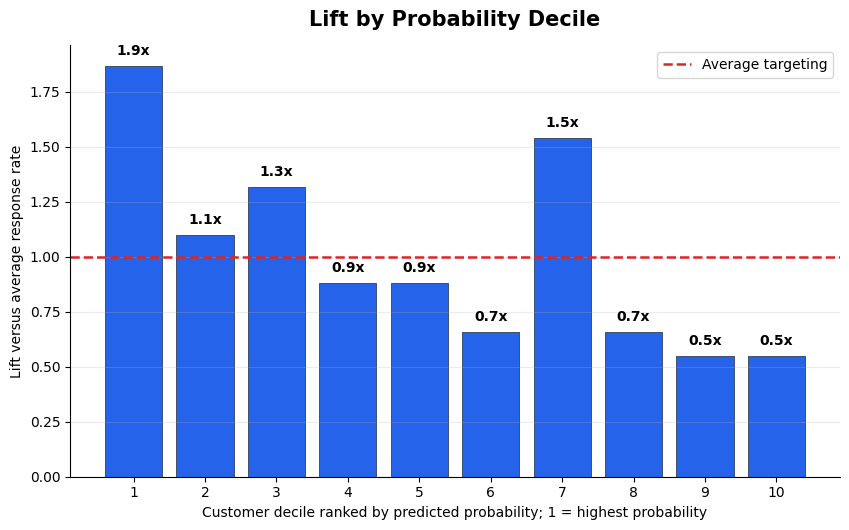

In [25]:
# ============================================================
# CELL 25 — LIFT CHART
# ============================================================

# Create a bar chart for decile lift.
fig, ax = plt.subplots(figsize=(8.6, 5.4))
ax.bar(lift_df["decile"].astype(str), lift_df["lift_vs_average"], color="#2563eb", edgecolor="#1f2937", linewidth=0.5)
ax.axhline(1.0, color="#dc2626", linestyle="--", linewidth=1.8, label="Average targeting")

# Add labels above bars.
for x, y_value in zip(lift_df["decile"].astype(str), lift_df["lift_vs_average"]):
    ax.text(x, y_value + 0.05, f"{y_value:.1f}x", ha="center", fontsize=10, fontweight="bold")

# Format chart.
ax.set_title("Lift by Probability Decile", fontsize=15, fontweight="bold", pad=14)
ax.set_xlabel("Customer decile ranked by predicted probability; 1 = highest probability")
ax.set_ylabel("Lift versus average response rate")
ax.legend(loc="upper right")
ax.grid(axis="y", alpha=0.25)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

show_conclusion(
    "Lift chart interpreted",
    f"Decile 1 delivers <b>{top_decile_lift:.2f}x</b> lift. A practical campaign team should start with the highest-probability deciles before expanding to lower-score groups."
)

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">28. Notebook 4 Theory Recap</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.64; font-size:15px;">
    <p><b>1. Logistic Regression is for classification.</b> Despite the word regression, it is used when the target is a class. In this notebook, the class is campaign response: 1 = responded, 0 = did not respond.</p>
    <p><b>2. The model predicts probabilities first.</b> Logistic Regression calculates a linear score from the features, then uses the sigmoid function to convert that score into a probability from 0 to 1.</p>
    <p><b>3. A threshold converts probability into a decision.</b> The default threshold is 0.50, but business teams can tune it. Lower thresholds capture more responders but also target more non-responders. Higher thresholds make the target list cleaner but may miss responders.</p>
    <p><b>4. Coefficients are interpreted through odds ratios.</b> A positive coefficient increases the log-odds of response. An odds ratio above 1 means the feature increases response odds. An odds ratio below 1 means the feature reduces response odds.</p>
    <p><b>5. Accuracy is not enough.</b> Campaign response is usually imbalanced, so precision, recall, F1, ROC-AUC, PR-AUC, calibration and lift are more useful for business decisions.</p>
    <p><b>6. Lift is the BI story.</b> A good campaign model should rank customers so the top-scored group has a much higher response rate than average. That is how Logistic Regression becomes useful in marketing, sales, churn prevention and customer analytics.</p>
  </div>
</div>

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">29. Final Business Recommendation</h2>
  </div>
  <div style="border:1px solid #bbf7d0; background:#f0fdf4; padding:16px 18px; border-radius:10px; line-height:1.64; font-size:15px;">
    <p><b>Recommended use:</b> use Logistic Regression as an interpretable probability-scoring model for customer targeting.</p>
    <p><b>How to use the model:</b> rank customers by predicted response probability, start with the highest-probability deciles, and choose the threshold based on campaign budget and acceptable false-positive cost.</p>
    <p><b>Dashboard layer:</b> show total targetable customers, expected responders, precision, recall, lift by decile, and top model drivers. This turns the model into an actionable BI decision system, not just a machine learning experiment.</p>
    <p><b>Risk note:</b> coefficients show association, not guaranteed causality. Before production use, validate on newer campaign data and monitor calibration and lift over time.</p>
  </div>
</div>

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">30. Final Coverage Checklist</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    <table style="border-collapse:collapse; width:100%; font-size:14px;">
      <tr style="background:#dbeafe;">
        <th style="border:1px solid #bfdbfe; padding:8px; text-align:left;">Topic</th>
        <th style="border:1px solid #bfdbfe; padding:8px; text-align:left;">Covered?</th>
      </tr>
      <tr><td style="border:1px solid #dbeafe; padding:8px;">Logistic Regression theory and use case</td><td style="border:1px solid #dbeafe; padding:8px;">Yes</td></tr>
      <tr><td style="border:1px solid #dbeafe; padding:8px;">Sigmoid probability conversion</td><td style="border:1px solid #dbeafe; padding:8px;">Yes</td></tr>
      <tr><td style="border:1px solid #dbeafe; padding:8px;">Binary classification workflow</td><td style="border:1px solid #dbeafe; padding:8px;">Yes</td></tr>
      <tr><td style="border:1px solid #dbeafe; padding:8px;">Train/test split with stratification</td><td style="border:1px solid #dbeafe; padding:8px;">Yes</td></tr>
      <tr><td style="border:1px solid #dbeafe; padding:8px;">Preprocessing pipeline and leakage prevention</td><td style="border:1px solid #dbeafe; padding:8px;">Yes</td></tr>
      <tr><td style="border:1px solid #dbeafe; padding:8px;">Accuracy, precision, recall, F1</td><td style="border:1px solid #dbeafe; padding:8px;">Yes</td></tr>
      <tr><td style="border:1px solid #dbeafe; padding:8px;">ROC-AUC and PR-AUC</td><td style="border:1px solid #dbeafe; padding:8px;">Yes</td></tr>
      <tr><td style="border:1px solid #dbeafe; padding:8px;">Confusion matrix</td><td style="border:1px solid #dbeafe; padding:8px;">Yes</td></tr>
      <tr><td style="border:1px solid #dbeafe; padding:8px;">Odds ratios and coefficient interpretation</td><td style="border:1px solid #dbeafe; padding:8px;">Yes</td></tr>
      <tr><td style="border:1px solid #dbeafe; padding:8px;">Threshold tuning</td><td style="border:1px solid #dbeafe; padding:8px;">Yes</td></tr>
      <tr><td style="border:1px solid #dbeafe; padding:8px;">Class imbalance and class weights</td><td style="border:1px solid #dbeafe; padding:8px;">Yes</td></tr>
      <tr><td style="border:1px solid #dbeafe; padding:8px;">Calibration curve and Brier score</td><td style="border:1px solid #dbeafe; padding:8px;">Yes</td></tr>
      <tr><td style="border:1px solid #dbeafe; padding:8px;">Lift and gains analysis</td><td style="border:1px solid #dbeafe; padding:8px;">Yes</td></tr>
      <tr><td style="border:1px solid #dbeafe; padding:8px;">Business recommendation layer</td><td style="border:1px solid #dbeafe; padding:8px;">Yes</td></tr>
    </table>
  </div>
</div>